##### <h1 style="text-align:center"> Drexel University </h1>
<h2 style = "text-align:center"> College of Computing and Informatics</h2>
<h2 style = "text-align:center">DSCI 631: Applied Machine Learning</h2>
<h3 style = "text-align:center">Assignment 2</h3>
<h4> </h4>


<h3 style="color:red; font-weight:bold; text-decoration: underline">DON'T FORGET TO PUT YOUR TEAM MEMBERS' NAMES BELOW</h3>
### TEAM MEMBERS: Manyu Ghildiyal, Silas McAllister-Spooner

### A. Assignment Overview
This assignment provides the opportunity for you to practice with various skills in feature analysis, feature selection, bclassification (imbalance handling), regression and model tuning.

<h4 style="color:blue; font-weight:bold">The goal of this assignment is to provide a realistic setting for a machine learning task. Therefore instructions will not specify the exact steps to carry out. Instead, it is part of the assignment to identify promising features, models and preprocessing methods and apply them as appropriate.</h4>


### B. What to Hand In

Sumbit a completed this Jupyter notebook.

### C. How to Hand In

Submit your Jupyter notebook file through the course website in the Blackboard Learn system.

### D. When to Hand In

1. Submit your assignment no later than 11:59 pm in the due date.
2. There will be a 10% (absolute value) deduction for each day of lateness, to a maximum of 3 days; assignments will not be accepted beyond that point. Missing work will earn a zero grade.

### E. Written Presentation Requirements (if applicable)
Images must be clear and legible. Assignments will be judged on the basis of visual appearance, grammatical correctness, and quality of writing, as well as their contents. Please make sure that the text of your assignments is well-structured, using paragraphs, full sentences, and other features of well-written presentation.

### F. Academic Honesty

Each student is required to submit the Academic Honesty Form at the beginning of the term to cover all the deliverables (for example: assignments, projects, quizzes). Each piece of work must be original. That means, individual quizzes must be done individually without discussing and collaborating with anybody else. Team assignments must be written and programmed by your own team members. No team should copy any piece of work from other teams. The Drexel University Academic Honesty Rules and Procedures (as stated in the student handbook) will be adhered to strictly.  

### G. Marking Schemes:

Marking assignments will be based on several aspects: presentation, correctness and coding styles.

For programming questions, 10% of the mark will be judged on the coding style.

The following is a set of guidelines for the coding style in this course:
1. Write a good comment.
2. Use appropriate indentations to indicate control flows and blocks of code.
3. When breaking up a long line, break it before an operator, not after.

### H. Answer the following questions:
**Your answer should be combined with code and brief text answer.** Please ensure that your Jupyter notebook does not have too much spurious output. If you like, you can share your notebook in progress with me on Kaggle: leiwangv (lw474@drexel.edu)


### Data for Binary Classification in this assignment:
* URL: https://www.kaggle.com/datasets/isathyam31/adult-income-prediction-classification?select=data.csv
* On Kaggel Notebook, you can add the data set by searching the above URL
* Column “salary” is the target label to classify.



#### Question 1-1:
Examine the features of the data. Identify which feature is continuous and which feature is categorical. Make some analyses and statistics, then use the results to discuss your selected predictors. You may also derive new features.

In [1]:
#Import Statements
import pandas as pd

from sklearn.model_selection import cross_validate
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from imblearn.ensemble import BalancedBaggingClassifier
from imblearn.ensemble import BalancedRandomForestClassifier

#Pipeline
from sklearn.pipeline import Pipeline

#Naive-Bayes
from sklearn.naive_bayes import GaussianNB
import numpy as np

#Decision Tree
from sklearn.tree import DecisionTreeClassifier

#Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV

In [2]:
#Obvious Statement to read the data
data_file = pd.read_csv('data.csv')

#Head shows the first 5 rows - More for debugging than anything
data_file.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,country,salary
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0


In [3]:
#Describe File
data_file.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,salary
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456,0.240810
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429,0.427581
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000,0.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000,0.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000,1.000000


In [4]:
#Check for Duplicates and Null Values
print("Duplicates")
print(data_file.duplicated().sum())
print()
print("Null Values:")
print(data_file.isna().sum())

Duplicates
24

Null Values:
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
country           0
salary            0
dtype: int64


In [5]:
#Check for Data Types
data_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  country         32561 non-null  object
 14  salary          32561 non-null  int64 
dtypes: int64(7), object(8)
memory usage: 3.7+ MB


In [6]:
#Top Values - Look at the Top....
print('Top 5 by Salary')
data_file.sort_values('salary',ascending=False).head()

Top 5 by Salary


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,country,salary
9079,39,Self-emp-inc,216473,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,60,United-States,1
13132,50,Local-gov,168672,Masters,14,Married-civ-spouse,Prof-specialty,Wife,White,Female,0,1902,40,United-States,1
32530,35,?,320084,Bachelors,13,Married-civ-spouse,?,Wife,White,Female,0,0,55,United-States,1
14916,38,Private,297449,Bachelors,13,Married-civ-spouse,Adm-clerical,Husband,White,Male,7298,0,50,United-States,1
32532,34,Private,204461,Doctorate,16,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,60,United-States,1


In [7]:
#and Bottom 5  for 'salary' to make Quick & Dirty Predictions. However, you might notice some issues
print('Bottom 5 by Salary')
data_file.sort_values('salary',ascending=True).head()

Bottom 5 by Salary


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,country,salary
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,0
17,32,Private,186824,HS-grad,9,Never-married,Machine-op-inspct,Unmarried,White,Male,0,0,40,United-States,0
18,38,Private,28887,11th,7,Married-civ-spouse,Sales,Husband,White,Male,0,0,50,United-States,0
21,54,Private,302146,HS-grad,9,Separated,Other-service,Unmarried,Black,Female,0,0,20,United-States,0
22,35,Federal-gov,76845,9th,5,Married-civ-spouse,Farming-fishing,Husband,Black,Male,0,0,40,United-States,0


##### Analysis:

This assignment examines a more complex, real-world dataset aimed at predicting income level. The target variable, salary, is encoded as a binary outcome (0 and 1), representing two income groups.

Before identifying feature roles, it is important to distinguish between variable types. Continuous variables are numerical and represent measurable quantities, whereas categorical variables represent discrete groups or labels.

Based on the dataset and its description, the categorical features include workclass, education, marital-status, occupation, relationship, race, sex, and country. The continuous features include age, fnlwgt, education-num, capital-gain, capital-loss, and hours-per-week. Among these, education-num is better interpreted as an ordinal variable (a ranked encoding of education level), and fnlwgt represents a census sampling weight rather than a direct individual characteristic. Although salary is numeric in form, it serves as the target variable and is excluded from the predictor set.

The dataset description provides useful context for refining feature selection. For instance, since fnlwgt reflects how many individuals a record represents, it is unlikely to contribute meaningfully to predicting a person’s income and may be excluded. Additionally, education and education-num encode the same information, therefore, retaining only education-num avoids redundancy while preserving the ordinal structure.

An initial exploratory (“quick and dirty”) analysis highlights several potentially strong predictors. Education emerges as a key factor: individuals in the higher income group are more likely to have a bachelor’s degree or higher, while those in the lower income group tend to have a high school education or less. This aligns with the expected relationship between education and earning potential. Marital-status and relationship also appear informative. Higher-income individuals are frequently categorized as “Married-civ-spouse” and identified as “Husband” or “Wife,” suggesting that household structure may be associated with income. Similarly, occupation is likely to be a strong predictor, as higher-paying professions (such as executive or specialized roles) are more common among top earners. Hours-per-week shows a noticeable pattern, with higher-income individuals often working 40 or more hours per week. While this relationship is not necessarily causal, it indicates that work intensity may be associated with higher earnings. In contrast, race and sex do not show a clear distinction in the limited sample observed, as both higher- and lower-income groups appear dominated by similar categories. However, this observation is preliminary and should be interpreted cautiously, as a full analysis may reveal more nuanced patterns. Finally, capital-gain and capital-loss are highly skewed variables, with most observations equal to zero. Despite this, non-zero values appear to be strongly associated with higher income. This suggests that transforming these features (for example, into binary indicators reflecting the presence or absence of gains/losses) could improve their usefulness in a predictive model.

#### Question 1-2:
Check if the target label is balanced or not, what is your strategy if imbalanced? apply your strategy.

In [8]:
# Equation is fairly simple.
# 1) Find all values in column which equal 0 and get the first value in shape
# 2) Divide what is above by total
# 3) Convert from decimal to percentage
num_0_percent = data_file[data_file['salary'] == 0].shape[0] / data_file['salary'].shape[0] * 100

#Redo of above
num_1_percent = data_file[data_file['salary'] == 1].shape[0] / data_file['salary'].shape[0] * 100

#Print Statements
print(f"Number of 0's in percentage {num_0_percent:.1f}" )
print(f"Number of 1's in percentage {num_1_percent:.1f}" )

Number of 0's in percentage 75.9
Number of 1's in percentage 24.1


No, the target label is clearly not balanced. As we can see from the code above, nearly 75% of the target label is 0. My strategy for my imbalanced dataset is to use "Ensemble Re-Sampling"

In [9]:
#NOTE - THIS WILL TAKE TIME. IT TOOK 3 MINUTES TO RUN FOR ME

# Extract target variable (what we are trying to predict)
# In this case, salary is the label we want to classify (0 or 1)
y = data_file['salary']

# Extract feature variables (in this case everything except the target column)
# We use pd.get_dummies to convert categorical variables into numeric form
# because machine learning models cannot work with text categories directly
X = pd.get_dummies(data_file.drop('salary', axis=1), drop_first=True)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y)

# Import ensemble model that handles class imbalance using built-in resampling
# BalancedBaggingClassifier reduces imbalance by under-sampling majority class
# within each bootstrap sample
resampled_data = BalancedBaggingClassifier(
    estimator=DecisionTreeClassifier(max_features='sqrt'),
    random_state=0,
    n_estimators=100
)

# Perform cross-validation on training data
# This splits training data into 10 folds and evaluates model performance multiple times
# We use ROC AUC and Average Precision because the dataset is imbalanced
scores = cross_validate(
    resampled_data,
    X_train,
    y_train,
    cv=10,
    scoring=('roc_auc', 'average_precision')
)

# Print performance results for Balanced Bagging model
print('Balanced Bagging')
print('AUC: %.2f, average precision: %.2f' %
      (scores['test_roc_auc'].mean(), scores['test_average_precision'].mean()))

print()

# Balanced Random Forest is another ensemble method that handles imbalance
# It builds multiple decision trees using balanced bootstrap samples
resampled_rf = BalancedRandomForestClassifier(random_state=0)

# Evaluate Balanced Random Forest using the same cross-validation approach
scores = cross_validate(
    resampled_rf,
    X_train,
    y_train,
    cv=10,
    scoring=('roc_auc', 'average_precision')
)

# Print performance results for Balanced Random Forest model
print('Balanced Random Forest')
print('AUC: %.2f, average precision: %.2f' %
      (scores['test_roc_auc'].mean(), scores['test_average_precision'].mean()))

Balanced Bagging
AUC: 0.91, average precision: 0.76

Balanced Random Forest
AUC: 0.91, average precision: 0.76


##### Explaining The Results:

Both Balanced Bagging and Balanced Random Forest achieved strong ROC AUC (around 0.91), indicating excellent class separation ability. The Average Precision (~0.76) shows good performance in identifying the minority class despite class imbalance.

#### Question 1-3:
Split the data into train and test data, then build Pipeline, apply transformer as needed, train 3 out of the following algorithms (Logistic Regression, Support Vector Machines, Naïve Bayes, K-Nearest Neighbors, Tree) with hyperparameter tuning, to classify the target variable. Compare the performance of different algorithms on Test set. Discuss your results and findings.

##### Logistic Regression

In [10]:
#Feature Selection
# Selecting a small subset of features that are likely to influence income prediction
features = ['education', 'marital-status', 'relationship', 'hours-per-week']

# Input features (X) and target variable (y)
X_Features = data_file[features]
Y_Target = data_file['salary']


# Train-Test Split
# Splitting data into training and testing sets
# We use stratify to preserve the original class distribution (important for imbalanced data)
# This ensures both train and test sets have similar proportions of salary classes (0 and 1)
X_train, X_test, y_train, y_test = train_test_split(
    X_Features,
    Y_Target,
    test_size=0.2,
    random_state=42,
    stratify=Y_Target
)


# Preprocessing Setup

categorical_features = ['education', 'marital-status', 'relationship']
numeric_features = ['hours-per-week']

# ColumnTransformer applies different transformations to different columns:
# - OneHotEncoder converts categorical variables into numeric format
# - StandardScaler scales numerical features to have similar ranges
# This ensures all features are in a machine-learning-friendly format

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('num', StandardScaler(), numeric_features)
])


# Build Machine Learning Pipeline
model = Pipeline([
    ('preprocess', preprocessor),
    ('classifier', LogisticRegression())
])


# Hyperparameter Tuning Setup
# We define different values of hyperparameters to test:
# - C controls regularization strength (smaller = stronger regularization)
# - class_weight helps handle class imbalance by giving more importance to minority class

param_grid = {
    'classifier__C': [0.01, 0.1, 1],
    'classifier__class_weight': [None, 'balanced']
}


# Grid Search (Model Optimization)
# GridSearchCV tries all combinations of hyperparameters using cross-validation
# cv=5 splits training data into 5 folds to ensure robust evaluation
# scoring='f1' is used because the dataset is imbalanced and F1 balances precision and recall
grid = GridSearchCV(
    model,
    param_grid,
    scoring='f1'
)


# Model Training
# Fit GridSearchCV on training data
# This finds the best combination of hyperparameters automatically
grid.fit(X_train, y_train)


# Evaluation on Test Data
# Predict on unseen test data using the best model found by GridSearchCV
predictions = grid.predict(X_test)

# Print performance metrics including precision, recall, and F1-score
# This helps evaluate how well the model performs on both classes
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.94      0.72      0.82      4945
           1       0.50      0.86      0.63      1568

    accuracy                           0.76      6513
   macro avg       0.72      0.79      0.73      6513
weighted avg       0.84      0.76      0.77      6513



##### Naïve Bayes

In [11]:
preprocessor2 = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
    ('num', StandardScaler(), numeric_features)
])

model2 = Pipeline([
    ('preporcess',preprocessor2),
    ('classifier',GaussianNB())
])

param_grid2 = {
    'classifier__var_smoothing': np.logspace(0,-9,num=100)
}

grid2 = GridSearchCV(
    model2,
    param_grid2,
    scoring = 'f1'
)

grid2.fit(X_train, y_train)
predictions2 = grid2.predict(X_test)
print(classification_report(y_test,predictions2))

              precision    recall  f1-score   support

           0       0.94      0.72      0.81      4945
           1       0.49      0.86      0.62      1568

    accuracy                           0.75      6513
   macro avg       0.72      0.79      0.72      6513
weighted avg       0.83      0.75      0.77      6513



#### Decision Tree

In [12]:
model3 = Pipeline([
    ('preprocess', preprocessor),
    ('classifier', DecisionTreeClassifier())
])

param_grid3 = {
    'classifier__max_depth':[3,7,10],
    'classifier__min_samples_split':[2,5,10]
}

grid3 = GridSearchCV(
    model3,
    param_grid3,
    scoring = 'f1'
)

grid3.fit(X_train,y_train)
predictions3 = grid3.predict(X_test)
print(classification_report(y_test, predictions3))

              precision    recall  f1-score   support

           0       0.85      0.92      0.89      4945
           1       0.68      0.50      0.58      1568

    accuracy                           0.82      6513
   macro avg       0.77      0.71      0.73      6513
weighted avg       0.81      0.82      0.81      6513



##### Analysis:

Before we get into what each classification report means, let us first define our terms, so we won't get confused:
* precision: how many of the predicted positive cases were actually correct.
    * How many false positives we have, where fewer false positives mean higher precision
* recall: how many of the actual positive cases were correctly identified.
    * How many false negatives we had, where fewer false negatives mean higher recall
* f1-score: How good is the model at being both correct (precision) and complete (recall) at the same time?
* support: the number of actual samples in each class in the dataset.
* accuracy: overall correctness of predictions
* macro avg: the average of metrics across all classes equally.
* weighted avg: the average of metrics weighted by class size (support).

Across all models, a consistent pattern is observed between the two salary classes (0 and 1). There is generally higher precision and lower recall for class 0, while class 1 shows lower precision but higher recall. This reflects the impact of class imbalance, where approximately 76% of the data belongs to class 0, causing models to be biased toward predicting the majority class more accurately.

For the minority class (1), models tend to increase recall at the cost of precision, meaning they identify more true high-income cases but also generate more false positives. The Decision Tree shows a slightly different behavior by being more conservative for class 1, resulting in higher precision but lower recall compared to Logistic Regression and Naïve Bayes.

Despite these differences, F1-scores remain relatively consistent across models. For class 0, F1-scores range from about 0.80 to 0.89, indicating strong and stable performance. For class 1, F1-scores are lower, around 0.55 to 0.69, reflecting the difficulty of correctly classifying the minority group.

Comparing models more directly:

* Logistic Regression and Naïve Bayes perform best in recall for class 1
* Decision Tree performs best in precision for class 1 and recall/F1 for class 0
* Logistic Regression achieves the best F1-score for class 1

Based on these results, the Decision Tree model is selected for the final task, as it provides the highest precision for the minority class (class 1). Since precision is prioritized over recall, this model is preferred because it produces more reliable positive predictions, even if it misses some true high-income cases.

#### Question 1-4:
Identify features that are important from your best model. Which features are most influential? Which features could be removed without decrease in performance? Does removing irrelevant features make your model better?

##### Best Features:

In [13]:
#Get The Best Decision Tree
best_tree = grid3.best_estimator_
importance_of_features = best_tree.named_steps['classifier'].feature_importances_

#Can't use the old categorical list thanks to OHE, so have to do this to extract it from OHE
encoded_names = best_tree.named_steps['preprocess'].named_transformers_['cat'].get_feature_names_out(categorical_features)
all_features_names = list(encoded_names) + numeric_features

importance_df = pd.DataFrame({
    'Feature': all_features_names,
    'Importance': importance_of_features
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df.head(10))

                               Feature  Importance
18  marital-status_ Married-civ-spouse    0.540062
29                      hours-per-week    0.101996
9                 education_ Bachelors    0.091825
12                  education_ Masters    0.081706
14              education_ Prof-school    0.057635
10                education_ Doctorate    0.044366
15             education_ Some-college    0.020335
11                  education_ HS-grad    0.013818
28                  relationship_ Wife    0.009778
8                 education_ Assoc-voc    0.008503


The most influential feature in the model is marital status, particularly the category “Married-civ-spouse,” which has the strongest impact on predictions. Education-related features collectively form another important group, indicating that higher educational attainment is strongly associated with higher income levels. Hours-per-week also appears as a secondary predictor, but its contribution is relatively smaller compared to marital status and education, suggesting that much of its predictive signal may overlap with these stronger variables. In contrast, relationship-related features show consistently low importance, indicating limited additional value once marital status and education are included. Based on this, a reduced feature set excluding hours-per-week was tested to evaluate whether model performance could be maintained with a simpler representation. The results showed that performance remained similar in terms of overall classification behavior, supporting the idea that hours-per-week provides only marginal additional information in the presence of the dominant features.

In [14]:
final_preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'),['marital-status','education'])
])

final_model = Pipeline([
    ('preprocesser',final_preprocessor),
    ('classifier',DecisionTreeClassifier())
])

final_grid = GridSearchCV(
    final_model,
    param_grid3,
    scoring = 'f1'
)

final_grid.fit(X_train,y_train)
final_predictions = final_grid.predict(X_test)
print(classification_report(y_test, final_predictions))

              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4945
           1       0.72      0.41      0.52      1568

    accuracy                           0.82      6513
   macro avg       0.78      0.68      0.71      6513
weighted avg       0.81      0.82      0.80      6513



##### Conclusion:

Focusing on precision as the primary evaluation metric, the reduced-feature model demonstrates a trade-off rather than a clear improvement. The model achieves higher precision for the positive class, meaning it produces fewer false positives when predicting high income. However, this improvement comes at the cost of reduced recall, indicating that the model misses more actual high-income individuals (i.e., more false negatives). The F1-score for the minority class also decreases, reflecting weaker overall balance for that class, while the majority class remains largely unchanged.

Overall, removing less influential features such as hours-per-week does not improve the model universally. Instead, it simplifies the model while shifting its behavior toward higher precision and lower recall. This suggests that while some features may contribute only marginal predictive power individually, they still help improve recall and overall classification balance when included. Therefore, removing features does not strictly improve performance — it changes the trade-off between precision and recall rather than increasing overall model quality.

### Data for part 2 in this assignment (price prediction):
* URL: https://www.kaggle.com/austinreese/craigslist-carstrucks-data
* On Kaggle Notebook, you can add the data set by searching the above URL
* Column "price" is the target variable to predict
* You do not have to use the whole dataset, it is strongly recommended that you subsample the data while developing your solution.
* The goal of this part is to provide a realistic setting for a machine learning task. Therefore instructions will not specify the exact steps to carry out. Instead, it is part of the assignment to identify promising features, models and preprocessing methods and apply them as appropriate.

#### Question 2-1:
Assemble a dataset consisting of predictors/features and target variable from subsampled data.

What features are relevant for the prediction task?
Are there any features that should be excluded because they leak the target information?
Show visualizations or statistics to support your selection.

##### Imports

In [15]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Lasso
from sklearn.model_selection import cross_val_score, KFold, RandomizedSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor

##### Load Data and Subsample

In [16]:
df = pd.read_csv('vehicles.csv')
subsample = df.sample(10000,random_state=42)

In [17]:
subsample.columns

Index(['id', 'url', 'region', 'region_url', 'price', 'year', 'manufacturer',
       'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status',
       'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color',
       'image_url', 'description', 'county', 'state', 'lat', 'long',
       'posting_date'],
      dtype='object')

In [18]:
subsample.head()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
100905,7315883828,https://lakeland.craigslist.org/ctd/d/lakeland...,lakeland,https://lakeland.craigslist.org,36990,2017.0,ford,f150 super cab lariat,good,6 cylinders,...,NaN,pickup,white,https://images.craigslist.org/00s0s_lRS7etJoVE...,Carvana is the safer way to buy a car During t...,NaN,fl,28.0400,-81.9600,2021-05-02T15:31:06-0400
143835,7314599643,https://quadcities.craigslist.org/ctd/d/waterl...,"quad cities, IA/IL",https://quadcities.craigslist.org,27995,2006.0,chevrolet,corvette,good,8 cylinders,...,NaN,convertible,black,https://images.craigslist.org/00101_aa4DyXpKu0...,2006 *** Chevrolet Corvette Convertible Conver...,NaN,il,42.4778,-92.3661,2021-04-29T18:46:35-0500
20235,7308399808,https://littlerock.craigslist.org/ctd/d/clinto...,little rock,https://littlerock.craigslist.org,78423,2015.0,chevrolet,corvette,NaN,8 cylinders,...,NaN,convertible,NaN,https://images.craigslist.org/00A0A_kJsL7mVMCg...,➔ Want to see more pictures?Paste this link to...,NaN,ar,38.4018,-93.7850,2021-04-17T14:01:33-0500
300734,7312663807,https://wheeling.craigslist.org/ctd/d/follansb...,northern panhandle,https://wheeling.craigslist.org,14000,2013.0,bmw,328i,NaN,NaN,...,NaN,NaN,NaN,https://images.craigslist.org/00K0K_2oCjTKrjd9...,"**Deals, Deals, Deals** Beautiful 2013 BMW 3-S...",NaN,oh,40.3203,-80.6250,2021-04-25T23:53:42-0400
316249,7315368523,https://eugene.craigslist.org/ctd/d/cottage-gr...,eugene,https://eugene.craigslist.org,676,2019.0,chevrolet,suburban ls,NaN,8 cylinders,...,NaN,NaN,black,https://images.craigslist.org/00H0H_3hFsa4lTxO...,2019 Chevrolet Suburban LS Brads Chevy - ☎️ ...,NaN,or,43.7839,-123.0529,2021-05-01T10:04:24-0700


In [19]:
subsample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 100905 to 251540
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            10000 non-null  int64  
 1   url           10000 non-null  object 
 2   region        10000 non-null  object 
 3   region_url    10000 non-null  object 
 4   price         10000 non-null  int64  
 5   year          9974 non-null   float64
 6   manufacturer  9611 non-null   object 
 7   model         9888 non-null   object 
 8   condition     5958 non-null   object 
 9   cylinders     5824 non-null   object 
 10  fuel          9916 non-null   object 
 11  odometer      9896 non-null   float64
 12  title_status  9788 non-null   object 
 13  transmission  9942 non-null   object 
 14  VIN           6205 non-null   object 
 15  drive         6990 non-null   object 
 16  size          2805 non-null   object 
 17  type          7884 non-null   object 
 18  paint_color   7010 non-nu

In [20]:
subsample.isna().sum()

id                  0
url                 0
region              0
region_url          0
price               0
year               26
manufacturer      389
model             112
condition        4042
cylinders        4176
fuel               84
odometer          104
title_status      212
transmission       58
VIN              3795
drive            3010
size             7195
type             2116
paint_color      2990
image_url           0
description         0
county          10000
state               0
lat               157
long              157
posting_date        0
dtype: int64

In [21]:
subsample.nunique()

id              10000
url             10000
region            392
region_url        404
price            2247
year               86
manufacturer       39
model            3509
condition           6
cylinders           8
fuel                5
odometer         7118
title_status        6
transmission        3
VIN              5624
drive               3
size                4
type               13
paint_color        12
image_url        9157
description      9852
county              0
state              51
lat              5045
long             5056
posting_date     9974
dtype: int64

##### Visualizations and Statistics

In [22]:
#Posting_date to Posting Year
subsample['posting_date'] = pd.to_datetime(subsample['posting_date'], utc=True)
subsample['post_year'] = subsample['posting_date'].dt.year
subsample['post_month'] = subsample['posting_date'].dt.month

##### Numeric Features

In [23]:
mean_price = subsample['price'].mean()

median_price = subsample['price'].median()

print(f'Mean price is {mean_price}')
print(f'Median price is {median_price}')

Mean price is 17968.9492
Median price is 13987.5


**Correlation Analysis of Numeric Features**

In [24]:
#Numeric Feature Names
numeric_cols = ['price', 'year', 'odometer']

#Fresh DF
df_numeric = subsample[numeric_cols]

#Compute Matrix
corr_matrix = df_numeric.corr()
print(corr_matrix)

             price      year  odometer
price     1.000000  0.149432 -0.071862
year      0.149432  1.000000 -0.160410
odometer -0.071862 -0.160410  1.000000


**Correlation Graph**

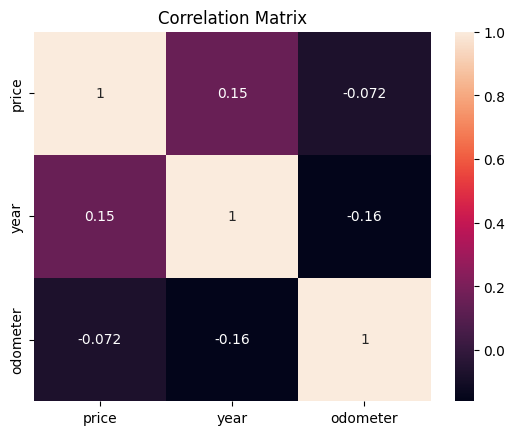

In [25]:
sns.heatmap(corr_matrix, annot=True)
plt.title('Correlation Matrix')
plt.show()

**Numeric Scatter Plots**

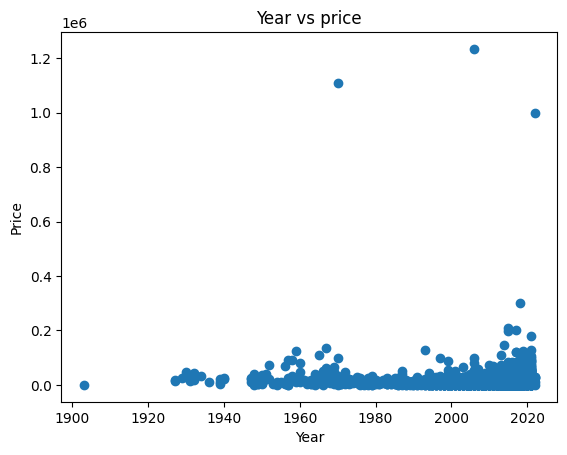

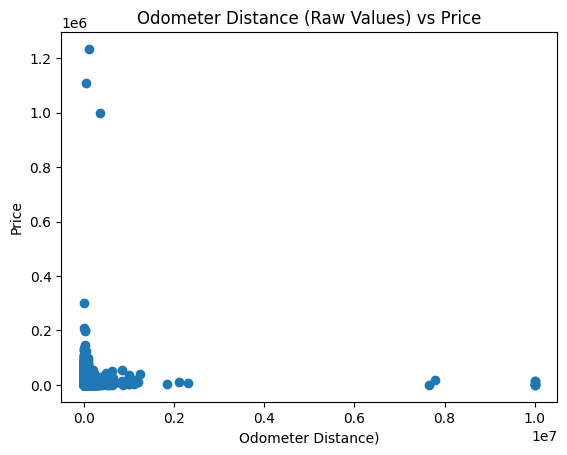

C:\Users\MANYU\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


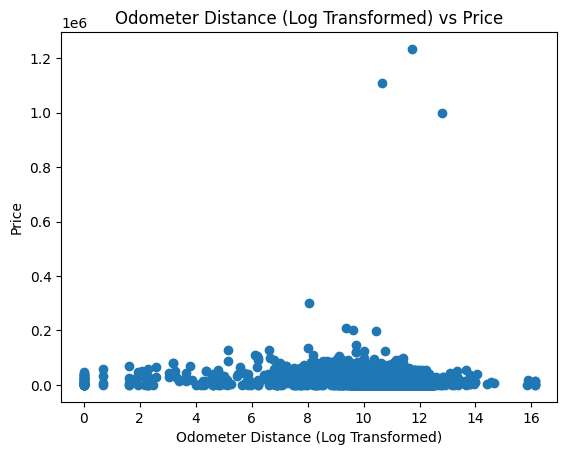

In [26]:
#Year vs Price
plt.scatter(subsample['year'], subsample['price'])
plt.title('Year vs price')
plt.xlabel('Year')
plt.ylabel('Price')
plt.show()

#Year vs Odometer (Raw)
plt.scatter(subsample['odometer'], subsample['price'])
plt.title('Odometer Distance (Raw Values) vs Price')
plt.xlabel('Odometer Distance)')
plt.ylabel('Price')
plt.show()

#Year vs Odometer (Log Transformed)
plt.scatter(np.log(subsample['odometer']), subsample['price'])
plt.title('Odometer Distance (Log Transformed) vs Price')
plt.xlabel('Odometer Distance (Log Transformed)')
plt.ylabel('Price')
plt.show()

**Numeric Histograms**

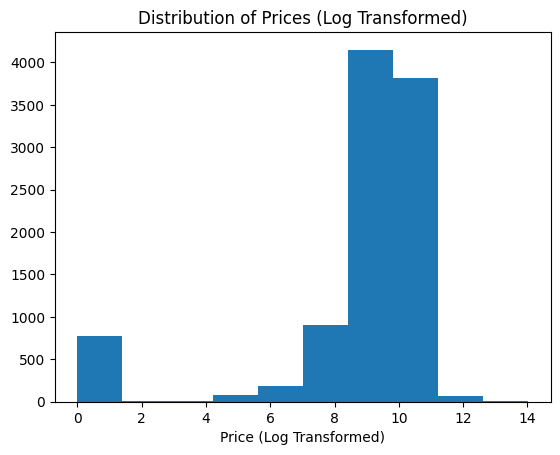

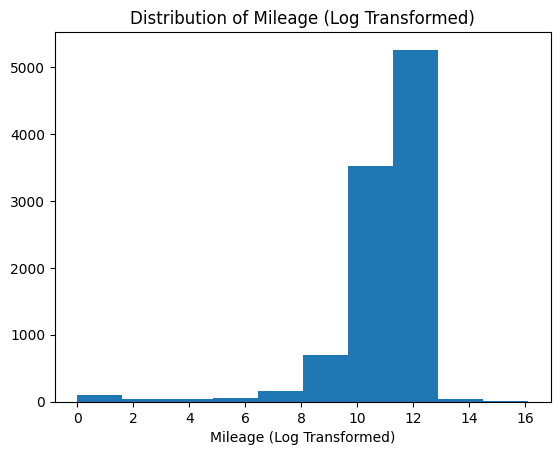

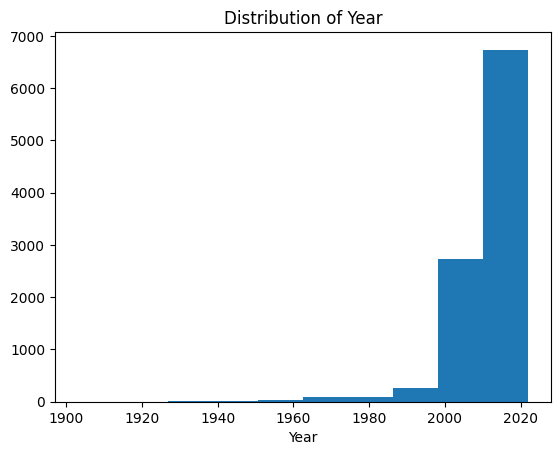

In [27]:
#Price Distribution
plt.hist(np.log1p(subsample['price']))
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Price (Log Transformed)')
plt.show()

#Odometer Distribution
plt.hist(np.log1p(subsample['odometer']))
plt.title('Distribution of Mileage (Log Transformed)')
plt.xlabel('Mileage (Log Transformed)')
plt.show()

#Year Distribution
plt.hist(subsample['year'])
plt.title('Distribution of Year')
plt.xlabel('Year')
plt.show()

##### Categorical Features

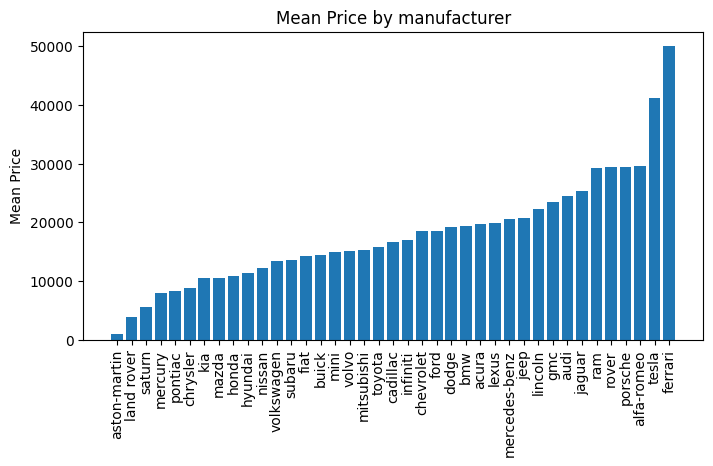

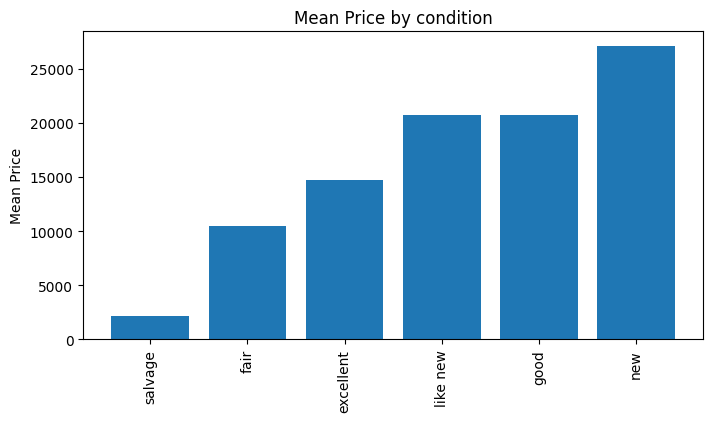

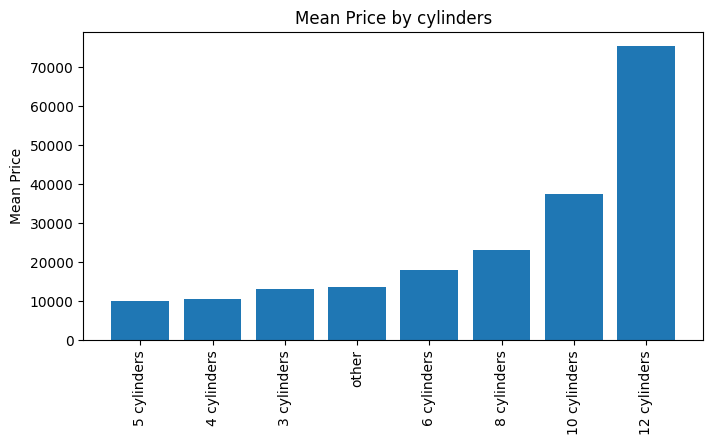

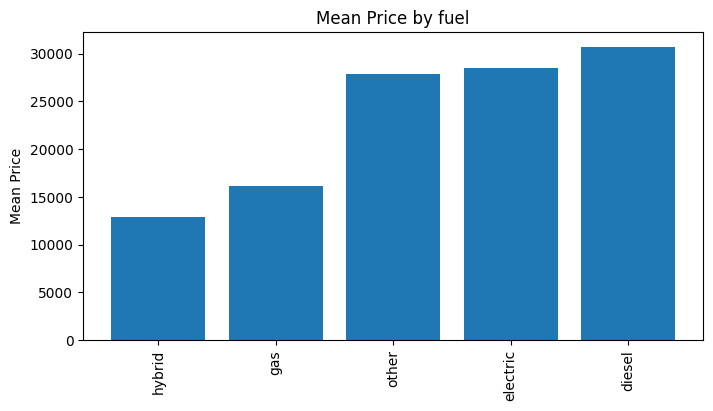

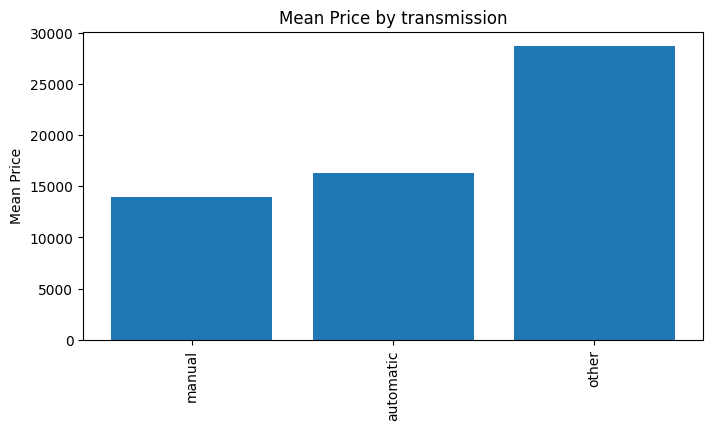

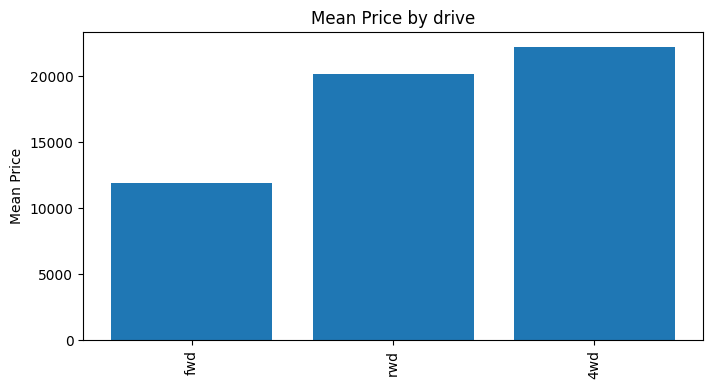

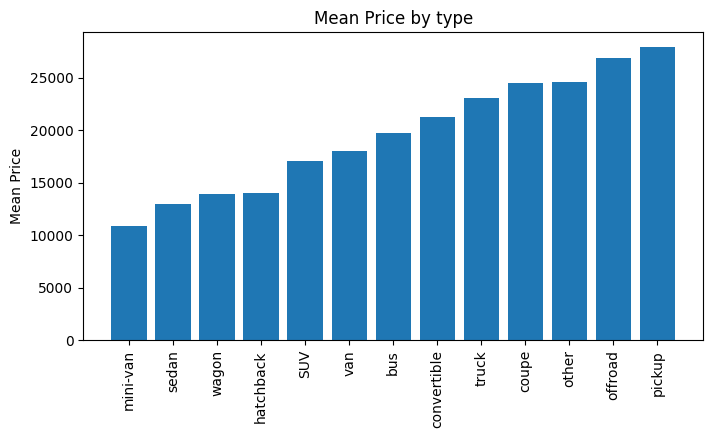

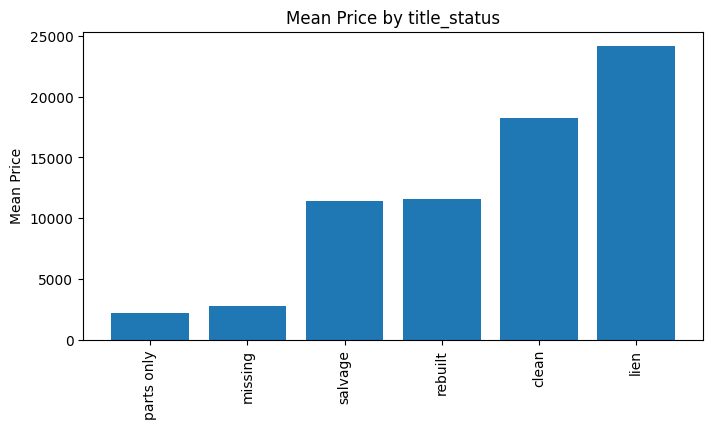

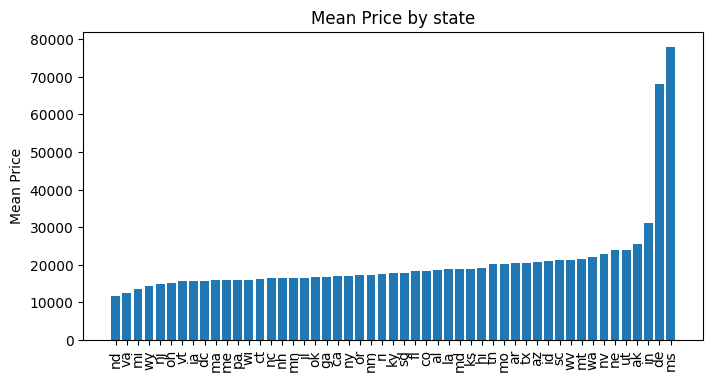

In [28]:
cat_cols = [
    'manufacturer',
    'condition',
    'cylinders',
    'fuel',
    'transmission',
    'drive',
    'type',
    'title_status',
    'state'
]

for col in cat_cols:
    grouped = subsample.groupby(col)['price'].mean().sort_values()

    plt.figure(figsize=(8,4))
    plt.bar(grouped.index.astype(str), grouped.values)
    plt.xticks(rotation=90)
    plt.title(f'Mean Price by {col}')
    plt.ylabel('Mean Price')
    plt.show()

##### Analysis

**General:**

A subsample size of 10,000 observations, representing approximately 2–3% of the full dataset, was chosen to improve computational efficiency while still providing a sufficiently large sample for exploratory analysis and model development. The sample is assumed to reasonably approximate overall patterns in the data.

**Excluded Features:**

Several features were excluded due to lack of usability or relevance. The unique identifiers (VIN, Url) were removed because they are high-cardinality identifier variables with limited predictive usefulness.. Unstructured text (description,image_URL) was dropped, as were overly granular variables such as model and region. Geographic coordinates Lat and Long were exluded in favor of State, which carries more interpretable regional meaning.

**Numeric Features:**

After cleaning, year showed a moderate positive correlation with price (r = 0.149), confirming its predictive value. Odometer shows a weaker negative correlation (r = -0.071), which understates its true importance given the non linear and conditional value of mileage on price. A log transformation was applied to normalize the distribution of price and reduce the influence of outliers on model training.

**Categorical Features:**

Among categorical features, condition, manufacturer, and cylinders show a clear separation of average price, indicating strong predictive value. All categorical features demonstrated predictive value in varying degree. Features such as fuel type, transmission, and drive demonstrate only moderate differences in price, likely contributing additional signal but worth keeping. County is exclusively NA values and can be dropped altogether.


#### Question 2-2:
Perform feature selection with a linear model, with appropriate preprocessing and cross-validation, evaluate the generalization performance.

**Set Up Transformers and Lasso Regression**

In [29]:
#Transformers
numeric_transformer = Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('standardscalar', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer',SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot',OneHotEncoder(handle_unknown='ignore'))
])

#Feature Name Lists
numeric = ['odometer','year']
categorical = cat_cols

#ColumnTransformer Setup
preprocessor = ColumnTransformer([
    ('numeric_transformer', numeric_transformer, numeric),
    ('categorical_transformer', categorical_transformer, categorical)
])

#L1 Lasso
model = Lasso(alpha=.01)

**Create X and Y**

In [30]:
X = subsample[numeric + categorical]
y = np.log1p(subsample['price'])

**Construct Pipeline and Fit**

In [31]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model',model)
])


**Run CV and Display Scores**

In [32]:
cv = KFold(n_splits=10, shuffle = True, random_state=42)

#Negative RMSE scores from Kfold CV (using 10 n_splits)
results = cross_validate(
    pipeline,
    X,
    y,
    cv=cv,
    scoring=['neg_root_mean_squared_error', 'r2']
)

print("RMSE:", -results['test_neg_root_mean_squared_error'].mean())
print("STD:", results['test_neg_root_mean_squared_error'].std())
print("R²:", results['test_r2'].mean())

print("\nNull model RMSE:", np.std(y))


RMSE: 2.6236896237355687
STD: 0.12929755913491361
R²: 0.06877546777825932

Null model RMSE: 2.7242636782773095


In [33]:
#Fit Pipeline
pipeline.fit(X,y)

#grab the model and feature names
model = pipeline.named_steps['model']
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

#Build Coefficients Dataframe
coefs = pd.DataFrame({
    'feature': feature_names,
    'coefficient': model.coef_
})

coefs = coefs.sort_values(by='coefficient', key=abs, ascending=False)

coefs

,feature,coefficient
138,categorical_transformer__state_va,-1.140729
67,categorical_transformer__transmission_other,0.745553
129,categorical_transformer__state_ok,-0.643780
130,categorical_transformer__state_or,-0.576908
81,categorical_transformer__type_pickup,0.517946
...,...,...
139,categorical_transformer__state_vt,-0.000000
140,categorical_transformer__state_wa,0.000000
141,categorical_transformer__state_wi,0.000000
142,categorical_transformer__state_wv,-0.000000


**Zeroed Values Count**

In [34]:
zeroed = (coefs['coefficient'] == 0).sum()
total = len(coefs)
print(f"Zeroed out: {zeroed} of {total} features")

Zeroed out: 113 of 144 features


##### Evaluation of Model Performance

**Performance**

The Lasso regression model showed limited generalization performance. Using 10-fold cross-validation, the model achieved:

* Mean RMSE: 2.62 (log-transformed price scale)
* RMSE Standard Deviation: 0.13
* Mean R^2: 0.069

The null model baseline (predicting the mean log-price for all observations) had an RMSE of 2.72, meaning the Lasso model improved prediction error by only about 0.10 RMSE over the baseline. This indicates that the linear model captures only a small portion of the variability in vehicle prices.

An R^2 value of approximately 0.07 means the model explains only about 7% of the variance in log-transformed prices. This suggests that the relationship between the predictors and vehicle price is likely nonlinear and more complex than what a sparse linear model can effectively represent.

Because the target variable was log-transformed using np.log1p(price), the RMSE is measured in log-price units rather than dollars. Therefore, interpreting the error directly as a dollar amount is not appropriate. However, the relatively high RMSE still indicates substantial prediction error after transforming back to the original price scale.

The low standard deviation across folds (≈0.13) suggests the model’s performance was relatively consistent across different train/test splits, even though overall predictive power remained weak.

**Feature Selection** 

After preprocessing and one-hot encoding, the dataset contained 144 total features. The Lasso model shrank 113 coefficients to exactly zero, leaving only 31 active predictors. This demonstrates the feature selection capability of L1 regularization, which removes variables that contribute little predictive value.

The largest remaining coefficients were associated primarily with:

* State variables, suggesting regional pricing differences strongly influence vehicle prices.
* Vehicle type indicators such as pickup trucks, which tend to command higher prices.
* Transmission categories, where the "other" category showed a positive coefficient, possibly reflecting specialty or manual vehicles.

The large number of zeroed coefficients indicates that many categorical levels added little useful information once regularization was applied. Overall, the model produced a sparse and interpretable set of predictors, though predictive accuracy remained limited.

#### Question 2-3:
Use any one or more non-linear regression model(s) we have introduced (tree, forest, gradient boosting, etc) to improve your result. You can (and probably should) change your preprocessing and feature engineering to be suitable for the model, tune hyperparameters as appropriate. What is the best prediction you can get? Discuss your work here.

You are not required to try all of these models.

**New Transformers**

In [35]:
#StandardScalar removed from Numeric Pipeline
numeric_transformer_tree = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

#One Hot Exchanged for Ordinal Encoder
categorical_transformer_tree = Pipeline([
    ('imputer',SimpleImputer(strategy='constant',fill_value='Unknown')),
    ('encoder',OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1))
])

preprocessor_tree = ColumnTransformer([
    ('numeric',numeric_transformer_tree,numeric),
    ('categorical',categorical_transformer_tree,categorical)
])

rf_pipeline = Pipeline([
    ('preprocessor',preprocessor_tree),
    ('model',RandomForestRegressor(random_state=42, n_jobs=-1))
])

In [36]:
#Parameters To Search Through
params = {
    'model__n_estimators':[100,200,500],
    'model__max_depth':[10,20,None],
    'model__min_samples_leaf':[1,10,50]
}

search = RandomizedSearchCV(
    rf_pipeline,
    params,
    n_iter=10,
    cv = 5, 
    scoring = 'neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

search.fit(X,y)

print(f'Best Params: {search.best_params_}')
print("Best CV RMSE (log):", -search.best_score_)

Best Params: {'model__n_estimators': 500, 'model__min_samples_leaf': 1, 'model__max_depth': 20}
Best CV RMSE (log): 2.4287817868180173


In [37]:
#StandardScalar removed from Numeric Pipeline
numeric_transformer_gb = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

#One Hot Exchanged for Ordinal Encoder
categorical_transformer_gb = Pipeline([
    ('imputer',SimpleImputer(strategy='constant',fill_value='Unknown')),
    ('encoder',OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1))
])

preprocessor_gb = ColumnTransformer([
    ('numeric',numeric_transformer_gb,numeric),
    ('categorical',categorical_transformer_gb,categorical)
])

gb_pipeline = Pipeline([
    ('preprocessor',preprocessor_gb),
    ('model',HistGradientBoostingRegressor(random_state=42))
])

Note: The following cell may produce ResourceTracker warnings on Python 3.13/macOS environments. These are a known cleanup artifact related to parallel processing and do not affect the results or validity of the search.

In [38]:
#Parameters To Search Through
params = {
    'model__learning_rate': [0.01, 0.03, 0.1],
    'model__max_iter': [100, 200, 500],
    'model__max_depth': [10,20,None],
    'model__min_samples_leaf': [1,10,50]
}

search = RandomizedSearchCV(
    gb_pipeline,
    params,
    n_iter=10,
    cv = 5, 
    scoring = 'neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

search.fit(X,y)

print(f'Best Params: {search.best_params_}')
print("Best CV RMSE (log):", -search.best_score_)

Best Params: {'model__min_samples_leaf': 10, 'model__max_iter': 200, 'model__max_depth': 10, 'model__learning_rate': 0.03}
Best CV RMSE (log): 2.4569051506701842


**Results and Analysis**

To improve on the previous linear model baseline from Q2-2, a Random forest Regressor was chosen for this modeling task to improve upon accuracy. Random forest was chosen as it is stronger in capturing non-linear and complex relationships between features, which is a major limiting factor for the lasso model. Gradient Boost was later tested to further inspect the degree to which the dataset was a limiting factor. 

**Preprocessing:**

Unlike linear regression models, Random Forest does not require feature standardization because tree-based methods are not sensitive to differences in feature scale. As a result, the StandardScaler step was removed from the numeric preprocessing pipeline. Additionally, one-hot encoding was replaced with ordinal encoding for categorical variables. This reduced the dimensionality of the dataset while still preserving categorical information for the tree-based models.

**Hyperparameter Tuning**

A RandomizedSearchCV with 5-fold cross-validation was conducted to tune the Random Forest model. The following hyperparameters were searched:
* n_estimators
* max_depth
* min_samples_leaf

The best-performing parameter combination was:
* n_estimators = 500
* max_depth = 20
* min_samples_leaf = 1

**Results**

The Random Forest model achieved a best cross-validated RMSE of 2.43 on the log-transformed price scale, improving upon the Lasso regression RMSE of approximately 2.62. For comparison, the null model had an RMSE of approximately 2.72. This means:

* The Lasso model improved the baseline by roughly 0.10 RMSE
* The Random Forest improved the baseline by roughly 0.29 RMSE

This indicates that the Random Forest captured substantially more predictive structure in the data than the linear model.

**Reasoning for Improvement**

Vehicle pricing is inherently non-linear and depends heavily on interactions between features. For example, a 2005 BMW with 80,000 miles may be worth more than a newer Dodge Caravan, while a high-mileage truck may retain value differently than a luxury sedan with similar mileage. Linear models attempt to assign fixed coefficients to each feature, applying the same effect across all observations. This limits their ability to capture complex feature interactions. Random Forest models handle these relationships more effectively by recursively partitioning the data into increasingly specific groups, allowing relationships such as mileage effects to vary across different vehicle types and categories.

**Limitations**

A Histogram Gradient Boosting model was also tested and achieved a cross-validated RMSE very similar to Random Forest (approximately 2.46 vs. 2.43). The relatively small difference between these models suggests that the dataset itself is likely the primary limitation on predictive performance, rather than the modeling approach. Because Craigslist listings are user-generated, the dataset likely contains substantial noise, including missing information, inconsistent descriptions, unrealistic pricing, and other data quality issues. Additionally, important predictors such as vehicle condition, accident history, maintenance records, and trim details may not be available. These limitations likely place an upper bound on achievable predictive accuracy.